<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%205/W05_L2_Recent_CNN_Architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=_ermvion1M0) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%205/NPTEL_Jul24_DL4CV_W05_P02.pdf)

# Week 5 | Lecture 2: More and Recent CNN Architectures

**Deep Learning for Computer Vision**

This lecture continues the story of convolutional network design past the original ResNet, walking through the modern ResNet family and the efficiency-focused blocks that power today's vision models. We build each architecture's signature block from scratch, verify its shapes and parameter cost, and explore its key hyperparameter with interactive sliders.

**Learning objectives**

- Build the modern ResNet-family and efficiency blocks from scratch and compare their compute cost.
- Understand **pre-activation ResNet** (clean identity path) and **WideResNet** (width vs depth).
- Understand **ResNeXt** cardinality via **grouped convolutions**, and **DenseNet** feature reuse via **concatenation**.
- Understand **MobileNet depthwise separable convolutions** and quantify the FLOP savings.
- Understand **EfficientNet compound scaling**, **SENet channel attention**, and the **ConvNeXt** modernizations.
- Read parameter and FLOP counts to reason about the accuracy vs efficiency spectrum.

## How to use this notebook

- **Self-contained:** everything runs inside the notebook, no external downloads required (we only use small random tensors).
- **Runs on CPU or GPU**, locally or on **Google Colab**. Every cell finishes in seconds; there is no training.
- **Interactive:** several cells expose sliders and dropdowns. Run the cell, then drag the slider and watch the plot or numbers update.
- **Block-centric:** for each architecture we build its key `nn.Module`, check output shape and parameter count, and study one hyperparameter.

In [1]:
# Setup: runs on CPU or GPU, on Colab or locally.
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ipywidgets is preinstalled on Colab; install only if missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, interactive

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

def count_params(module):
    "Total number of parameters in a module."
    return sum(p.numel() for p in module.parameters())

def count_trainable(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

Using device: cpu


## 1. Recap: the residual block

**Why it matters.** The residual (skip) connection lets a block learn a residual $F(x)$ that is added to the input: $y = F(x) + x$. This keeps gradients flowing through very deep networks and made 100+ layer training practical.

**The basic block (ResNet-18/34 style):**

- Two $3\times3$ convolutions, each followed by **BatchNorm** and **ReLU**.
- A **skip connection** adds the input to the output.
- If the number of channels or the spatial size changes, the skip uses a $1\times1$ conv to match shapes.

We build a small `BasicBlock` helper here and reuse the pattern throughout.

In [2]:
def conv3x3(cin, cout, stride=1):
    return nn.Conv2d(cin, cout, kernel_size=3, stride=stride, padding=1, bias=False)

class BasicBlock(nn.Module):
    "Standard post-activation residual block: conv-BN-ReLU x2 + skip."
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = conv3x3(cin, cout, stride)
        self.bn1   = nn.BatchNorm2d(cout)
        self.conv2 = conv3x3(cout, cout)
        self.bn2   = nn.BatchNorm2d(cout)
        # 1x1 projection on the skip if shape changes
        self.skip = nn.Sequential()
        if stride != 1 or cin != cout:
            self.skip = nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(cout))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.skip(x)
        return F.relu(out)

blk = BasicBlock(64, 64)
x = torch.randn(1, 64, 32, 32)
y = blk(x)
print('input  :', tuple(x.shape))
print('output :', tuple(y.shape))
print('params :', count_params(blk))

input  : (1, 64, 32, 32)
output : (1, 64, 32, 32)
params : 73984


## 2. Pre-activation ResNet (He et al., Identity Mappings, 2016)

**Why it matters.** In the original block the addition is followed by a ReLU, so the identity path is not truly clean: the signal that flows to the next block has already passed through a nonlinearity. **Pre-activation** moves **BatchNorm and ReLU to before each convolution**, leaving the skip path a pure identity. This improves gradient flow and lets even deeper nets (1000+ layers) train.

**Ordering change:**

- Original: `conv -> BN -> ReLU` (activation after conv, ReLU after the add).
- Pre-activation: `BN -> ReLU -> conv` (activation before conv, nothing on the skip).

With pre-activation, $y = x + F(x)$ where the $+x$ path has **no** BN or ReLU on it, so gradients reach earlier layers unchanged.

In [3]:
class OriginalBlock(nn.Module):
    "conv -> BN -> ReLU (post-activation), ReLU after the add."
    def __init__(self, c):
        super().__init__()
        self.conv1, self.bn1 = conv3x3(c, c), nn.BatchNorm2d(c)
        self.conv2, self.bn2 = conv3x3(c, c), nn.BatchNorm2d(c)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + x)              # ReLU sits on the identity path

class PreActBlock(nn.Module):
    "BN -> ReLU -> conv (pre-activation); the skip stays a clean identity."
    def __init__(self, c):
        super().__init__()
        self.bn1, self.conv1 = nn.BatchNorm2d(c), conv3x3(c, c)
        self.bn2, self.conv2 = nn.BatchNorm2d(c), conv3x3(c, c)
    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        return out + x                      # nothing on the identity path

c = 64
xo = torch.randn(2, c, 16, 16)
ob, pb = OriginalBlock(c), PreActBlock(c)
print('Original   out:', tuple(ob(xo).shape), '| params:', count_params(ob))
print('PreAct     out:', tuple(pb(xo).shape), '| params:', count_params(pb))
print()
print('Original order : conv -> BN -> ReLU, then ReLU(out + x)')
print('PreAct   order : BN -> ReLU -> conv, then (out + x)  <- clean skip')

Original   out: (2, 64, 16, 16) | params: 73984
PreAct     out: (2, 64, 16, 16) | params: 73984

Original order : conv -> BN -> ReLU, then ReLU(out + x)
PreAct   order : BN -> ReLU -> conv, then (out + x)  <- clean skip


## 3. Wide Residual Networks (Zagoruyko and Komodakis, 2016)

**Why it matters.** Instead of stacking ever more layers, WideResNet makes each block **wider**: multiply the number of filters by a **width factor $k$** (use $F \cdot k$ filters). Key findings:

- **Width can beat depth:** a shallower but wider net can match a much deeper thin one. A roughly 50-layer wide net can match a 152-layer ResNet.
- **Wider is more parallelizable** on GPUs than deeper, because wide layers use larger, more efficient matrix multiplies.
- Cost grows **quadratically** in $k$ (both convs see $k\times$ channels), so it is a knob to trade compute for accuracy.

Build a `WideBlock` with a width multiplier $k$, then use a slider to watch the parameter count grow like $k^2$.

In [4]:
class WideBlock(nn.Module):
    "Residual block whose base width F is multiplied by width factor k."
    def __init__(self, cin, F_base=16, k=1, stride=1):
        super().__init__()
        cout = F_base * k
        self.bn1, self.conv1 = nn.BatchNorm2d(cin), conv3x3(cin, cout, stride)
        self.bn2, self.conv2 = nn.BatchNorm2d(cout), conv3x3(cout, cout)
        self.skip = nn.Sequential()
        if stride != 1 or cin != cout:
            self.skip = nn.Conv2d(cin, cout, 1, stride=stride, bias=False)
    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        return out + self.skip(x)

for k in (1, 2, 4, 8):
    b = WideBlock(16, F_base=16, k=k)
    print(f'k={k:>2}  width={16*k:>3}  params={count_params(b):>8,}')

k= 1  width= 16  params=   4,672
k= 2  width= 32  params=  14,432
k= 4  width= 64  params=  47,264
k= 8  width=128  params= 168,224


**Try this.** Drag the $k$ slider. Notice the parameter count scales roughly like $k^2$: doubling the width roughly quadruples the parameters, because both the input and output channels of the inner conv grow with $k$.

In [5]:
def wide_widget(F_base=16, k=1):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ks = np.arange(1, 13)
    params = [count_params(WideBlock(F_base, F_base=F_base, k=int(kk))) for kk in ks]
    ax.plot(ks, params, 'o-', color='steelblue')
    ax.scatter([k], [count_params(WideBlock(F_base, F_base=F_base, k=k))],
               color='crimson', zorder=5, s=80)
    ax.set_xlabel('width factor k'); ax.set_ylabel('parameters')
    ax.set_title(f'WideBlock params vs k  (F_base={F_base}, k={k}: '
                 f'{count_params(WideBlock(F_base, F_base=F_base, k=k)):,} params)')
    ax.grid(alpha=0.3)
    plt.show()

interact(wide_widget,
         F_base=widgets.IntSlider(min=8, max=64, step=8, value=16, description='F_base'),
         k=widgets.IntSlider(min=1, max=12, step=1, value=1, description='width k'));

interactive(children=(IntSlider(value=16, description='F_base', max=64, min=8, step=8), IntSlider(value=1, des…

## 4. ResNeXt (Xie et al., 2017)

**Why it matters.** ResNeXt introduces a new dimension called **cardinality**: the number of parallel transformation pathways inside a block. It follows a **split-transform-merge** strategy (like Inception) but every pathway is identical and repeatable, so the block stays simple.

- **Cardinality = number of groups.** Instead of one full convolution over all channels, split the channels into $C$ groups and convolve each group independently. This is exactly a **grouped convolution**: `nn.Conv2d(..., groups=cardinality)`.
- A grouped conv with $C$ groups costs about $1/C$ of the FLOPs of the equivalent full-width conv, so you can **increase cardinality instead of depth or width** to gain accuracy at similar cost.
- The block uses a $1\times1$ reduce, a grouped $3\times3$ transform, and a $1\times1$ expand (a bottleneck).

Build a `ResNeXtBlock`, confirm the output shape is preserved, then use a slider to see how grouped conv is cheaper than a full-width conv.

In [6]:
class ResNeXtBlock(nn.Module):
    "Bottleneck block with a grouped 3x3 conv; groups = cardinality."
    def __init__(self, cin, cout, cardinality=32, width=4, stride=1):
        super().__init__()
        # bottleneck width scales with cardinality
        D = cardinality * width
        self.conv1 = nn.Conv2d(cin, D, 1, bias=False); self.bn1 = nn.BatchNorm2d(D)
        self.conv2 = nn.Conv2d(D, D, 3, stride=stride, padding=1,
                               groups=cardinality, bias=False); self.bn2 = nn.BatchNorm2d(D)
        self.conv3 = nn.Conv2d(D, cout, 1, bias=False); self.bn3 = nn.BatchNorm2d(cout)
        self.skip = nn.Sequential()
        if stride != 1 or cin != cout:
            self.skip = nn.Sequential(nn.Conv2d(cin, cout, 1, stride=stride, bias=False),
                                      nn.BatchNorm2d(cout))
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        return F.relu(out + self.skip(x))

blk = ResNeXtBlock(256, 256, cardinality=32, width=4)
x = torch.randn(1, 256, 14, 14)
print('input :', tuple(x.shape), '-> output:', tuple(blk(x).shape))
print('params:', count_params(blk))

input : (1, 256, 14, 14) -> output: (1, 256, 14, 14)
params: 71168


**Try this.** Move the cardinality slider. We compare the grouped $3\times3$ conv (the transform inside the block) against a single full-width $3\times3$ conv over the same channels. Notice that raising cardinality **shrinks** the grouped conv cost, because each group only mixes $1/C$ of the channels.

In [7]:
def resnext_widget(cardinality=32, width=4):
    D = cardinality * width
    grouped = nn.Conv2d(D, D, 3, padding=1, groups=cardinality, bias=False)
    full    = nn.Conv2d(D, D, 3, padding=1, groups=1, bias=False)
    pg, pf = count_params(grouped), count_params(full)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(['grouped (C=%d)' % cardinality, 'full-width (C=1)'], [pg, pf],
           color=['seagreen', 'gray'])
    for i, v in enumerate([pg, pf]):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom')
    ax.set_ylabel('params in the 3x3 conv')
    ax.set_title(f'D={D} channels  |  grouped is {pf/pg:.1f}x cheaper')
    plt.show()

interact(resnext_widget,
         cardinality=widgets.IntSlider(min=1, max=32, step=1, value=8, description='cardinality'),
         width=widgets.IntSlider(min=2, max=8, step=1, value=4, description='width'));

interactive(children=(IntSlider(value=8, description='cardinality', max=32, min=1), IntSlider(value=4, descrip…

## 5. DenseNet (Huang et al., 2017)

**Why it matters.** DenseNet takes feature reuse to the extreme: **every layer receives the concatenation of ALL previous feature maps** as its input, and passes its own output on to every later layer.

- Each layer adds only a small number of channels, the **growth rate $k$**. After $L$ layers a block that started with $C_{in}$ channels has $C_{in} + L \cdot k$ channels.
- Concatenation (not addition) means features are **reused** rather than summed, which **strengthens gradient flow** and makes the network **parameter-efficient**: each layer is thin, yet has access to all earlier features.
- A `DenseLayer` here is BN -> ReLU -> $3\times3$ conv producing $k$ channels; a `DenseBlock` stacks $L$ of them with `torch.cat`.

Build them, verify the channel count grows as $C_{in} + L\cdot k$, then explore $k$ and $L$ with sliders.

In [8]:
class DenseLayer(nn.Module):
    "BN -> ReLU -> 3x3 conv producing exactly k new channels."
    def __init__(self, cin, growth):
        super().__init__()
        self.bn, self.conv = nn.BatchNorm2d(cin), conv3x3(cin, growth)
    def forward(self, x):
        new = self.conv(F.relu(self.bn(x)))
        return torch.cat([x, new], dim=1)   # concatenate, do not add

class DenseBlock(nn.Module):
    def __init__(self, cin, growth=12, num_layers=6):
        super().__init__()
        layers, c = [], cin
        for _ in range(num_layers):
            layers.append(DenseLayer(c, growth)); c += growth
        self.block = nn.Sequential(*layers)
        self.out_channels = c
    def forward(self, x):
        return self.block(x)

Cin, k, L = 32, 12, 6
db = DenseBlock(Cin, growth=k, num_layers=L)
x = torch.randn(1, Cin, 28, 28)
y = db(x)
print(f'in channels : {Cin}')
print(f'out channels: {tuple(y.shape)[1]}  (formula C_in + L*k = {Cin} + {L}*{k} = {Cin + L*k})')
print(f'params      : {count_params(db):,}')

in channels : 32
out channels: 104  (formula C_in + L*k = 32 + 6*12 = 104)
params      : 40,920


**Try this.** Increase the growth rate $k$ or the number of layers $L$. The bar chart shows the channel width after each layer growing linearly, ending at $C_{in} + L\cdot k$. Notice how a small $k$ keeps each layer thin while the block still ends up wide.

In [9]:
def dense_widget(growth=12, num_layers=6, Cin=32):
    db = DenseBlock(Cin, growth=growth, num_layers=num_layers)
    channels = [Cin + i * growth for i in range(1, num_layers + 1)]
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.bar(range(1, num_layers + 1), channels, color='mediumpurple')
    ax.set_xlabel('layer index'); ax.set_ylabel('channels after layer')
    ax.set_title(f'C_in={Cin}, k={growth}, L={num_layers}  ->  '
                 f'out={db.out_channels} ch, {count_params(db):,} params')
    plt.show()

interact(dense_widget,
         growth=widgets.IntSlider(min=4, max=48, step=4, value=12, description='growth k'),
         num_layers=widgets.IntSlider(min=1, max=16, step=1, value=6, description='layers L'),
         Cin=widgets.IntSlider(min=16, max=64, step=16, value=32, description='C_in'));

interactive(children=(IntSlider(value=12, description='growth k', max=48, min=4, step=4), IntSlider(value=6, d…

## 6. MobileNet: depthwise separable convolution (Howard et al., 2017)

**Why it matters.** A standard $k\times k$ conv mixes across space **and** across all channels at once, which is expensive. MobileNet **factorizes** it into two cheap steps:

1. **Depthwise conv:** one $k\times k$ filter **per input channel** (`groups=C_in`). It mixes only over space, not across channels.
2. **Pointwise conv:** a $1\times1$ conv that mixes across channels.

**Cost reduction.** For $N$ output channels and kernel size $k$, the depthwise separable conv costs a fraction

$$\frac{1}{N} + \frac{1}{k^2}$$

of a standard conv. For $N=256, k=3$ that is about $\tfrac{1}{256} + \tfrac{1}{9} \approx 0.115$, roughly an **8 to 9x** reduction.

We build `DepthwiseSeparableConv` from scratch and verify the measured FLOP ratio matches $1/N + 1/k^2$. We also introduce the **width multiplier $\alpha$** (scale channel counts) and **resolution multiplier $\rho$** (scale input resolution), both of which scale cost quadratically.

In [10]:
class DepthwiseSeparableConv(nn.Module):
    "Depthwise (per-channel kxk) followed by pointwise (1x1) convolution."
    def __init__(self, cin, cout, k=3, stride=1):
        super().__init__()
        self.depthwise = nn.Conv2d(cin, cin, k, stride=stride, padding=k // 2,
                                   groups=cin, bias=False)      # one filter per channel
        self.bn1 = nn.BatchNorm2d(cin)
        self.pointwise = nn.Conv2d(cin, cout, 1, bias=False)    # mix across channels
        self.bn2 = nn.BatchNorm2d(cout)
    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

def conv_flops(cin, cout, k, H, W, groups=1):
    "Multiply-add count for a conv producing HxW output (per group accounting)."
    return (cin // groups) * cout * k * k * H * W

Cin, N, k, H, W = 128, 256, 3, 32, 32
# standard conv FLOPs
std = conv_flops(Cin, N, k, H, W)
# depthwise separable: depthwise (groups=Cin) + pointwise (1x1)
dw  = conv_flops(Cin, Cin, k, H, W, groups=Cin)
pw  = conv_flops(Cin, N, 1, H, W)
dsc = dw + pw

print(f'standard conv  FLOPs : {std:,}')
print(f'depthwise+point FLOPs: {dsc:,}  (dw {dw:,} + pw {pw:,})')
print(f'measured ratio dsc/std : {dsc/std:.4f}')
print(f'formula 1/N + 1/k^2    : {1/N + 1/k**2:.4f}')

# sanity check the module runs and preserves spatial size
m = DepthwiseSeparableConv(Cin, N, k=k)
xt = torch.randn(1, Cin, H, W)
print('module out shape:', tuple(m(xt).shape), '| params:', count_params(m))

standard conv  FLOPs : 301,989,888
depthwise+point FLOPs: 34,734,080  (dw 1,179,648 + pw 33,554,432)
measured ratio dsc/std : 0.1150
formula 1/N + 1/k^2    : 0.1150
module out shape: (1, 256, 32, 32) | params: 34688


**Try this (answers the slide homework "by what fraction is computation reduced").** Set the kernel size $k$, output channels $N$, and spatial size, then compare standard vs depthwise separable FLOPs. The measured ratio should track the formula $1/N + 1/k^2$ closely. Larger $k$ and larger $N$ both make the separable version relatively cheaper.

In [11]:
def dsc_widget(k=3, N=256, spatial=32, Cin=128):
    std = conv_flops(Cin, N, k, spatial, spatial)
    dsc = conv_flops(Cin, Cin, k, spatial, spatial, groups=Cin) + conv_flops(Cin, N, 1, spatial, spatial)
    ratio, formula = dsc / std, 1 / N + 1 / k**2

    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    ax.bar(['standard', 'depthwise\nseparable'], [std, dsc], color=['gray', 'darkorange'])
    for i, v in enumerate([std, dsc]):
        ax.text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom')
    ax.set_ylabel('multiply-add FLOPs')
    ax.set_title(f'k={k}, N={N}, HxW={spatial}x{spatial}  |  '
                 f'ratio={ratio:.3f}  (1/N+1/k^2={formula:.3f}), '
                 f'{std/dsc:.1f}x cheaper')
    plt.show()

interact(dsc_widget,
         k=widgets.IntSlider(min=1, max=7, step=2, value=3, description='kernel k'),
         N=widgets.IntSlider(min=32, max=512, step=32, value=256, description='out N'),
         spatial=widgets.IntSlider(min=8, max=64, step=8, value=32, description='H=W'),
         Cin=widgets.IntSlider(min=32, max=256, step=32, value=128, description='in C'));

interactive(children=(IntSlider(value=3, description='kernel k', max=7, min=1, step=2), IntSlider(value=256, d…

**Width and resolution multipliers.** MobileNet exposes two global knobs:

- **Width multiplier $\alpha$**: multiply every channel count by $\alpha$. Cost scales like $\alpha^2$ (both $C_{in}$ and $C_{out}$ shrink).
- **Resolution multiplier $\rho$**: multiply the input resolution by $\rho$. Cost scales like $\rho^2$ (fewer spatial positions $H\times W$).

The cell below shows both scalings on our example conv.

In [12]:
base = conv_flops(128, 256, 3, 32, 32)
print('base FLOPs:', f'{base:,}')
for alpha in (1.0, 0.75, 0.5, 0.25):
    c = conv_flops(int(128*alpha), int(256*alpha), 3, 32, 32)
    print(f'alpha={alpha:>4}: {c:>14,}  ({c/base:.3f}x, ~alpha^2={alpha**2:.3f})')
print()
for rho in (1.0, 0.857, 0.714, 0.571):   # e.g. 224,192,160,128 over 224
    s = int(round(32*rho))
    c = conv_flops(128, 256, 3, s, s)
    print(f'rho={rho:>5}: {c:>14,}  ({c/base:.3f}x, ~rho^2={rho**2:.3f})')

base FLOPs: 301,989,888
alpha= 1.0:    301,989,888  (1.000x, ~alpha^2=1.000)
alpha=0.75:    169,869,312  (0.562x, ~alpha^2=0.562)
alpha= 0.5:     75,497,472  (0.250x, ~alpha^2=0.250)
alpha=0.25:     18,874,368  (0.062x, ~alpha^2=0.062)

rho=  1.0:    301,989,888  (1.000x, ~rho^2=1.000)
rho=0.857:    214,990,848  (0.712x, ~rho^2=0.734)
rho=0.714:    156,008,448  (0.517x, ~rho^2=0.510)
rho=0.571:     95,551,488  (0.316x, ~rho^2=0.326)


## 7. EfficientNet: compound scaling (Tan and Le, 2019)

**Why it matters.** Earlier nets scaled just one dimension (deeper, or wider, or higher resolution). EfficientNet scales **all three together** with a single **compound coefficient $\phi$**:

$$\text{depth } d = \alpha^{\phi}, \quad \text{width } w = \beta^{\phi}, \quad \text{resolution } r = \gamma^{\phi}$$

subject to the constraint

$$\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2 .$$

**Why that constraint?** FLOPs grow linearly with depth but **quadratically** with width and resolution, so total FLOPs scale like $\alpha \cdot \beta^2 \cdot \gamma^2$ raised to $\phi$. Setting the product near $2$ means **each unit of $\phi$ roughly doubles the FLOPs**, so total cost grows as $\approx 2^{\phi}$. The defaults from the paper are $\alpha=1.2, \beta=1.1, \gamma=1.15$.

The widget below (answering the other slide homework) plots the FLOPs factor against $\phi$ and shows it tracks $2^{\phi}$.

In [13]:
def efficientnet_scaling(phi, alpha=1.2, beta=1.1, gamma=1.15):
    d = alpha ** phi           # depth multiplier
    w = beta  ** phi           # width multiplier
    r = gamma ** phi           # resolution multiplier
    flops_factor = d * (w ** 2) * (r ** 2)   # linear in depth, quadratic in width & res
    return d, w, r, flops_factor

for phi in range(0, 6):
    d, w, r, f = efficientnet_scaling(phi)
    print(f'phi={phi}: depth x{d:.2f}, width x{w:.2f}, res x{r:.2f}, '
          f'FLOPs x{f:.2f}  (2^phi = {2**phi})')

phi=0: depth x1.00, width x1.00, res x1.00, FLOPs x1.00  (2^phi = 1)
phi=1: depth x1.20, width x1.10, res x1.15, FLOPs x1.92  (2^phi = 2)
phi=2: depth x1.44, width x1.21, res x1.32, FLOPs x3.69  (2^phi = 4)
phi=3: depth x1.73, width x1.33, res x1.52, FLOPs x7.08  (2^phi = 8)
phi=4: depth x2.07, width x1.46, res x1.75, FLOPs x13.60  (2^phi = 16)
phi=5: depth x2.49, width x1.61, res x2.01, FLOPs x26.11  (2^phi = 32)


**Try this.** Drag $\phi$ and optionally change $\alpha, \beta, \gamma$. The red curve is the actual FLOPs factor $\alpha^{\phi}\beta^{2\phi}\gamma^{2\phi}$; the dashed line is $2^{\phi}$. With the default coefficients (whose product $\alpha\beta^2\gamma^2 \approx 2$) the two curves nearly coincide.

In [14]:
def compound_widget(phi=1.0, alpha=1.2, beta=1.1, gamma=1.15):
    d, w, r, f = efficientnet_scaling(phi, alpha, beta, gamma)
    phis = np.linspace(0, 6, 60)
    factors = [efficientnet_scaling(p, alpha, beta, gamma)[3] for p in phis]

    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(phis, factors, color='crimson', label=r'$\alpha^\phi\beta^{2\phi}\gamma^{2\phi}$ (actual)')
    ax.plot(phis, 2**phis, '--', color='navy', label=r'$2^\phi$ (target)')
    ax.scatter([phi], [f], color='crimson', s=80, zorder=5)
    ax.set_xlabel(r'compound coefficient $\phi$'); ax.set_ylabel('FLOPs factor')
    ax.set_title(f'phi={phi:.1f}: depth x{d:.2f}, width x{w:.2f}, res x{r:.2f}, '
                 f'FLOPs x{f:.2f}\nproduct a*b^2*g^2 = {alpha*beta**2*gamma**2:.2f}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.show()

interact(compound_widget,
         phi=widgets.FloatSlider(min=0, max=6, step=0.25, value=1.0, description='phi'),
         alpha=widgets.FloatSlider(min=1.0, max=1.6, step=0.05, value=1.2, description='alpha'),
         beta=widgets.FloatSlider(min=1.0, max=1.4, step=0.05, value=1.1, description='beta'),
         gamma=widgets.FloatSlider(min=1.0, max=1.4, step=0.05, value=1.15, description='gamma'));

interactive(children=(FloatSlider(value=1.0, description='phi', max=6.0, step=0.25), FloatSlider(value=1.2, de…

## 8. SENet: Squeeze-and-Excitation (Hu et al., 2018)

**Why it matters.** Not all channels are equally useful for a given input. SE blocks add cheap **channel attention** that learns to reweight channels per input.

- **Squeeze:** global average pool each channel to a single number, giving a per-channel descriptor of length $C$.
- **Excitation:** a tiny bottleneck MLP, FC (reduce by ratio $r$) -> ReLU -> FC (restore to $C$) -> **Sigmoid**, producing a gate in $(0,1)$ for each channel.
- **Scale:** multiply each channel of the feature map by its gate.

It is a **plug-in** module with very few parameters (set by the reduction ratio $r$) that recalibrates channel importance. Build `SEBlock` from scratch, apply it to a random feature map, and inspect the learned per-channel scales.

In [15]:
class SEBlock(nn.Module):
    "Squeeze-and-Excitation channel attention."
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(1, channels // reduction)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)
    def forward(self, x):
        b, c, _, _ = x.shape
        s = x.mean(dim=(2, 3))              # squeeze: global average pool -> (b, c)
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))      # excitation: gates in (0,1)
        return x * s.view(b, c, 1, 1), s    # scale each channel by its gate

C = 64
se = SEBlock(C, reduction=16)
x = torch.randn(1, C, 16, 16)
y, gates = se(x)
print('input :', tuple(x.shape), '-> output:', tuple(y.shape))
print('SE params:', count_params(se), '| gate range: '
      f'[{gates.min():.3f}, {gates.max():.3f}]')

input : (1, 64, 16, 16) -> output: (1, 64, 16, 16)
SE params: 580 | gate range: [0.381, 0.624]


**Try this.** Change the reduction ratio $r$. A larger $r$ means a tighter bottleneck and **fewer parameters**. The bar chart shows the per-channel attention gates the (untrained) block produces for a random input; after training these would emphasize the informative channels.

In [16]:
def se_widget(reduction=16, channels=64):
    torch.manual_seed(0)
    se = SEBlock(channels, reduction=reduction)
    x = torch.randn(1, channels, 16, 16)
    _, gates = se(x)
    g = gates.detach().numpy().ravel()

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(range(channels), g, color='teal')
    ax.axhline(0.5, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('channel index'); ax.set_ylabel('attention gate (0,1)')
    ax.set_title(f'reduction r={reduction}: hidden={max(1, channels//reduction)}, '
                 f'SE params={count_params(se):,}')
    plt.show()

interact(se_widget,
         reduction=widgets.IntSlider(min=1, max=32, step=1, value=16, description='reduction r'),
         channels=widgets.IntSlider(min=16, max=128, step=16, value=64, description='channels'));

interactive(children=(IntSlider(value=16, description='reduction r', max=32, min=1), IntSlider(value=64, descr…

## 9. ConvNeXt (Liu et al., 2022)

**Why it matters.** ConvNeXt asks: how far can a pure ConvNet go if we borrow the design choices that made Vision Transformers strong? The answer is a modernized ResNet that matches transformers. Key changes:

- **Patchify stem:** a $4\times4$, stride-4 conv that splits the image into non-overlapping patches (like a ViT tokenizer).
- **Depthwise conv with a large $7\times7$ kernel:** a big receptive field per channel, cheaply.
- **Inverted bottleneck:** $1\times1$ **expand** to a wider hidden dim, then $1\times1$ **reduce** back.
- **Fewer activations and norms**, **GELU** instead of ReLU, **LayerNorm** instead of BatchNorm.
- **Separate downsampling layers** between stages.

Build a `ConvNeXtBlock` (depthwise $7\times7$ -> LayerNorm -> $1\times1$ expand -> GELU -> $1\times1$ reduce -> residual add) and forward a random tensor.

In [17]:
class LayerNorm2d(nn.Module):
    "LayerNorm over the channel dim for (B, C, H, W) tensors."
    def __init__(self, c, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(c))
        self.bias   = nn.Parameter(torch.zeros(c))
        self.eps = eps
    def forward(self, x):
        u = x.mean(1, keepdim=True)
        s = (x - u).pow(2).mean(1, keepdim=True)
        x = (x - u) / torch.sqrt(s + self.eps)
        return self.weight[None, :, None, None] * x + self.bias[None, :, None, None]

class ConvNeXtBlock(nn.Module):
    "Depthwise 7x7 -> LN -> 1x1 expand -> GELU -> 1x1 reduce, + residual."
    def __init__(self, dim, expansion=4):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 7, padding=3, groups=dim)   # large-kernel depthwise
        self.norm   = LayerNorm2d(dim)
        self.pw1    = nn.Conv2d(dim, expansion * dim, 1)              # expand
        self.act    = nn.GELU()
        self.pw2    = nn.Conv2d(expansion * dim, dim, 1)             # reduce
    def forward(self, x):
        y = self.dwconv(x)
        y = self.norm(y)
        y = self.pw2(self.act(self.pw1(y)))
        return x + y                                                  # residual

dim = 96
blk = ConvNeXtBlock(dim, expansion=4)
x = torch.randn(1, dim, 28, 28)
print('input :', tuple(x.shape), '-> output:', tuple(blk(x).shape))
print('params:', count_params(blk), '| expansion=4')

input : (1, 96, 28, 28) -> output: (1, 96, 28, 28)
params: 79200 | expansion=4


**Try this.** The plot compares **GELU** (ConvNeXt) with **ReLU**. GELU is a smooth gate that lets small negative values through slightly, unlike ReLU's hard cutoff at zero. The slider also lets you change the inverted-bottleneck **expansion ratio** and see its effect on the block's parameter count.

In [18]:
def convnext_widget(expansion=4, dim=96):
    blk = ConvNeXtBlock(dim, expansion=expansion)
    z = torch.linspace(-4, 4, 200)
    gelu = F.gelu(z).numpy()
    relu = F.relu(z).numpy()

    fig, ax = plt.subplots(figsize=(6.5, 3.8))
    ax.plot(z.numpy(), gelu, color='crimson', label='GELU (ConvNeXt)')
    ax.plot(z.numpy(), relu, '--', color='navy', label='ReLU')
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_xlabel('input'); ax.set_ylabel('activation')
    ax.set_title(f'GELU vs ReLU  |  ConvNeXtBlock(dim={dim}, expansion={expansion}): '
                 f'{count_params(blk):,} params')
    ax.legend(); ax.grid(alpha=0.3)
    plt.show()

interact(convnext_widget,
         expansion=widgets.IntSlider(min=1, max=8, step=1, value=4, description='expansion'),
         dim=widgets.IntSlider(min=32, max=192, step=32, value=96, description='dim'));

interactive(children=(IntSlider(value=4, description='expansion', max=8, min=1), IntSlider(value=96, descripti…

## 10. Cost comparison of the signature blocks

To feel the **efficiency spectrum**, we build one block per architecture at the **same input and output channels** and compare parameter counts. Depthwise separable and grouped blocks sit at the cheap end; wide and dense-heavy blocks sit at the expensive end. (Exact numbers depend on the internal width choices, but the ordering is the lesson.)

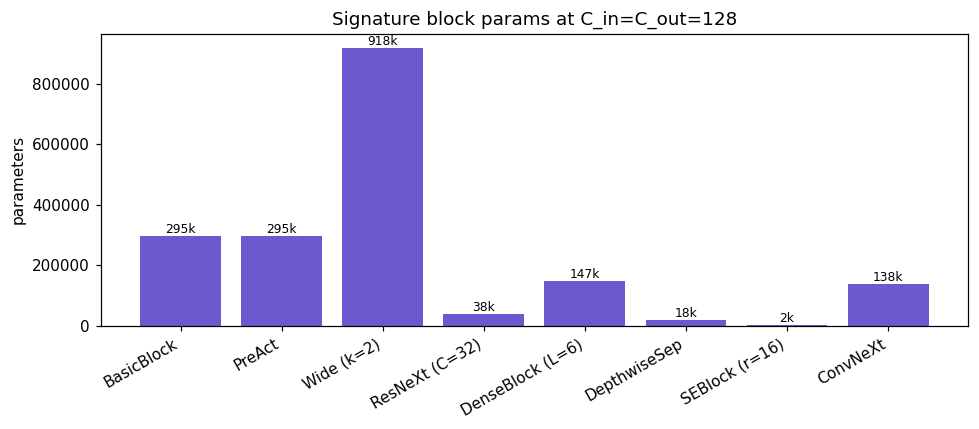

SEBlock (r=16)            2,184 params
DepthwiseSep             18,048 params
ResNeXt (C=32)           38,144 params
ConvNeXt                138,368 params
DenseBlock (L=6)        147,168 params
BasicBlock              295,424 params
PreAct                  295,424 params
Wide (k=2)              918,272 params


In [19]:
C = 128
blocks = {
    'BasicBlock':        BasicBlock(C, C),
    'PreAct':            PreActBlock(C),
    'Wide (k=2)':        WideBlock(C, F_base=C, k=2),
    'ResNeXt (C=32)':    ResNeXtBlock(C, C, cardinality=32, width=4),
    'DenseBlock (L=6)':  DenseBlock(C, growth=16, num_layers=6),
    'DepthwiseSep':      DepthwiseSeparableConv(C, C, k=3),
    'SEBlock (r=16)':    SEBlock(C, reduction=16),
    'ConvNeXt':          ConvNeXtBlock(C, expansion=4),
}
names  = list(blocks.keys())
params = [count_params(b) for b in blocks.values()]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, params, color='slateblue')
for b, p in zip(bars, params):
    ax.text(b.get_x() + b.get_width()/2, p, f'{p/1e3:.0f}k', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('parameters'); ax.set_title(f'Signature block params at C_in=C_out={C}')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.show()

for n, p in sorted(zip(names, params), key=lambda t: t[1]):
    print(f'{n:<20} {p:>10,} params')

## Key takeaways

- **Pre-activation ResNet** keeps the identity path clean (BN -> ReLU -> conv), improving gradient flow in very deep nets.
- **WideResNet** trades depth for **width $k$**; cost grows like $k^2$, and width is more parallel-friendly.
- **ResNeXt** adds **cardinality** via **grouped convolutions**: split-transform-merge with identical pathways, cheaper than full-width convs.
- **DenseNet** concatenates all previous features (growth rate $k$, channels $C_{in}+Lk$), maximizing reuse and parameter efficiency.
- **MobileNet** factorizes convs into **depthwise + pointwise**, cutting cost to $1/N + 1/k^2$; $\alpha$ and $\rho$ scale it further ($\sim\alpha^2$, $\sim\rho^2$).
- **EfficientNet** scales depth, width, and resolution **jointly** with $\phi$ under $\alpha\beta^2\gamma^2\approx2$, so FLOPs grow like $2^{\phi}$.
- **SENet** adds cheap **channel attention** (squeeze, excitation, scale) that recalibrates channels per input.
- **ConvNeXt** modernizes ResNet with a patchify stem, large-kernel depthwise conv, inverted bottleneck, GELU, and LayerNorm.
- Reading **parameter and FLOP counts** is the practical skill: it tells you where a block sits on the accuracy vs efficiency spectrum.

## Further reading

- He, Zhang, Ren, Sun. Identity Mappings in Deep Residual Networks, 2016.
- Huang, Liu, van der Maaten, Weinberger. Densely Connected Convolutional Networks (DenseNet), 2017.
- Howard et al. MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications, 2017.
- Tan, Le. EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks, 2019.
- Hu, Shen, Sun. Squeeze-and-Excitation Networks (SENet), 2018.
- Liu et al. A ConvNet for the 2020s (ConvNeXt), 2022.